Lab Assignment 3: Phoneme Segmentation and Voicing Analysis in Speech


Objective 1

In [3]:
import librosa


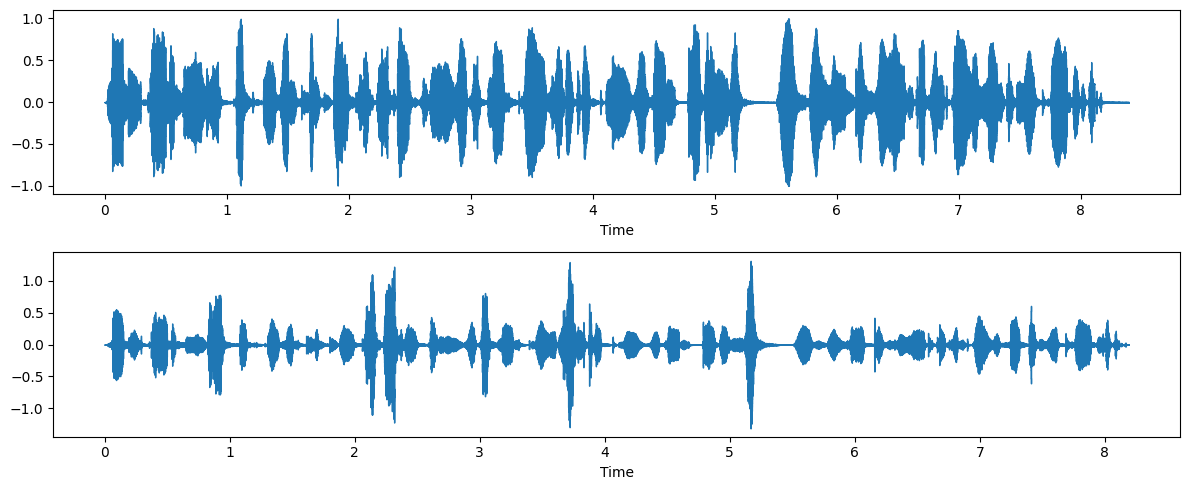

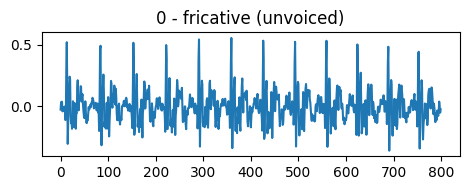

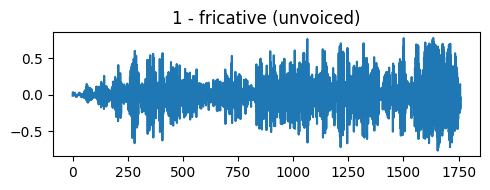

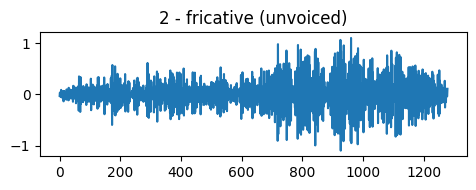

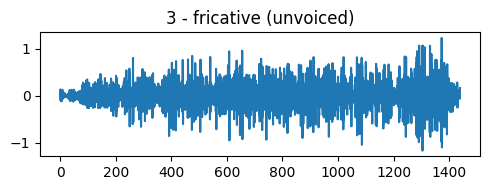

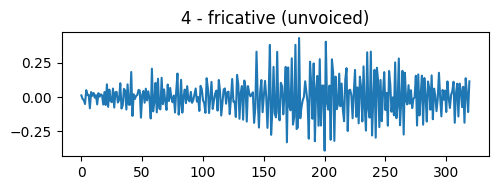

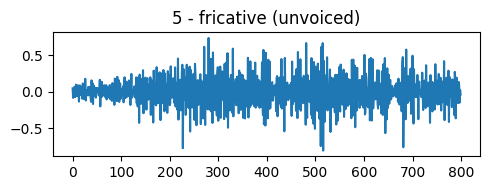

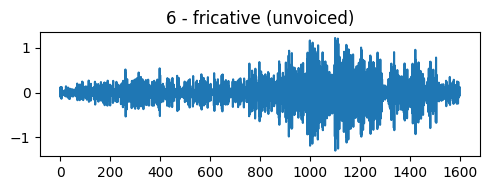

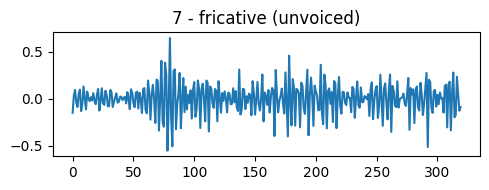

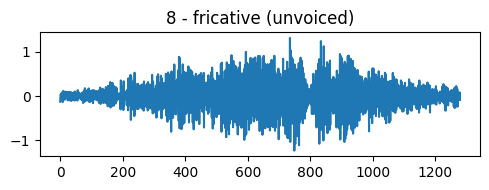

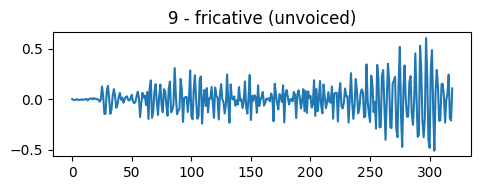

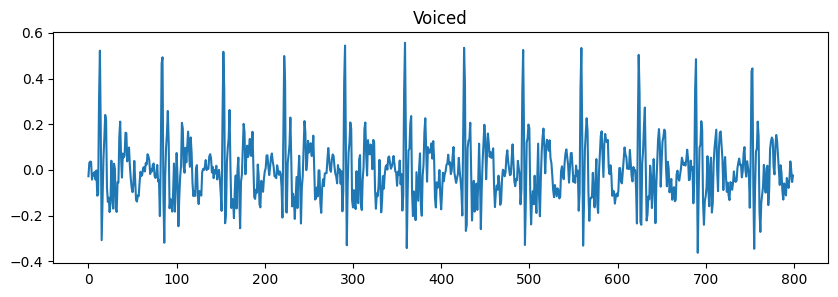

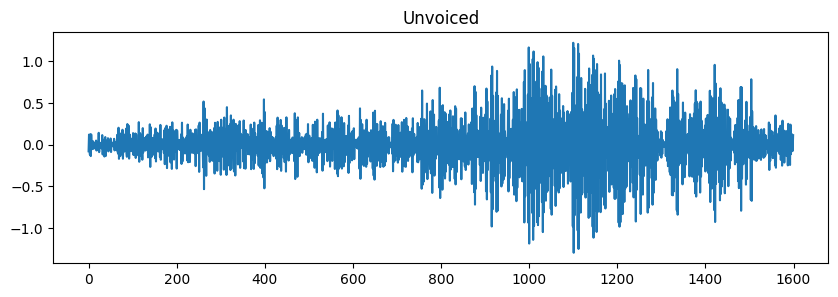

Voiced: 0.2842857142857143 0.11906005
Unvoiced: 0.829 22.360886


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf


audio_path = "LJ025-0076.wav"

signal, sr = librosa.load(audio_path, sr=16000, mono=True)

signal = signal / (np.max(np.abs(signal)) + 1e-8)

trimmed_signal, _ = librosa.effects.trim(signal, top_db=20)

if len(trimmed_signal) == 0:
    trimmed_signal = signal

pre_emphasis = 0.97
preprocessed_signal = np.append(
    trimmed_signal[0],
    trimmed_signal[1:] - pre_emphasis * trimmed_signal[:-1]
)

sf.write("preprocessed_speech.wav", preprocessed_signal, sr)


plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
librosa.display.waveshow(signal, sr=sr)
plt.subplot(2,1,2)
librosa.display.waveshow(preprocessed_signal, sr=sr)
plt.tight_layout()
plt.show()


frame_len = int(0.02 * sr)
hop_len = int(0.01 * sr)

frames = librosa.util.frame(
    preprocessed_signal,
    frame_length=frame_len,
    hop_length=hop_len
).T

energy = np.sum(frames**2, axis=1)
zcr = np.mean(librosa.zero_crossings(frames, axis=1), axis=1)


threshold = 0.05 * np.max(energy)
activity = energy > threshold


segments = []
start = None

for i, a in enumerate(activity):
    if a and start is None:
        start = i
    elif not a and start is not None:
        segments.append((start, i))
        start = None

if len(segments) == 0:
    segments = [(0, len(preprocessed_signal)//hop_len)]


waveforms = [
    preprocessed_signal[s*hop_len:e*hop_len]
    for s, e in segments
]


labels = []

for seg in waveforms:

    if len(seg) < 200:
        labels.append("plosive/affricate")
        continue

    f = librosa.util.frame(
        seg,
        frame_length=200,
        hop_length=100
    ).T

    E = np.mean(np.sum(f**2, axis=1))
    Z = np.mean(librosa.zero_crossings(f, axis=1))

    if Z < 0.08:
        labels.append("vowel (voiced)")
    elif Z > 0.18:
        labels.append("fricative (unvoiced)")
    else:
        labels.append("semivowel/diphthong")


for i, seg in enumerate(waveforms):
    plt.figure(figsize=(5,2))
    plt.plot(seg)
    plt.title(f"{i} - {labels[i]}")
    plt.tight_layout()
    plt.show()


zcr_vals = []

for seg in waveforms:
    if len(seg) < 200:
        zcr_vals.append(1.0)
    else:
        f = librosa.util.frame(
            seg,
            frame_length=200,
            hop_length=100
        ).T
        zcr_vals.append(np.mean(librosa.zero_crossings(f, axis=1)))


voiced = waveforms[np.argmin(zcr_vals)]
unvoiced = waveforms[np.argmax(zcr_vals)]


plt.figure(figsize=(10,3))
plt.plot(voiced)
plt.title("Voiced")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(unvoiced)
plt.title("Unvoiced")
plt.show()


def analyze(seg):
    if len(seg) < 200:
        return np.mean(librosa.zero_crossings(seg)), np.std(seg**2)

    f = librosa.util.frame(
        seg,
        frame_length=200,
        hop_length=100
    ).T

    z = np.mean(librosa.zero_crossings(f, axis=1))
    en = np.std(np.sum(f**2, axis=1))
    return z, en


vz, ve = analyze(voiced)
uz, ue = analyze(unvoiced)

print("Voiced:", vz, ve)
print("Unvoiced:", uz, ue)


2. Automatically segment the speech into phoneme-level units.


In [12]:
import librosa
import numpy as np

y, sr = librosa.load("preprocessed_speech.wav", sr=16000)

frame_len = int(0.02 * sr)
hop_len = int(0.01 * sr)

frames = librosa.util.frame(
    y,
    frame_length=frame_len,
    hop_length=hop_len
).T

energy = np.sum(frames**2, axis=1)
zcr = np.mean(librosa.zero_crossings(frames, axis=1), axis=1)

threshold = 0.05 * np.max(energy)
activity = energy > threshold

segments = []
start = None

for i, a in enumerate(activity):
    if a and start is None:
        start = i
    elif not a and start is not None:
        segments.append((start, i))
        start = None

print("Segments:")
for s, e in segments:
    print(round(s*hop_len/sr,3), "→", round(e*hop_len/sr,3))


Segments:
0.06 → 0.13
0.82 → 0.93
2.08 → 2.16
2.23 → 2.32
2.6 → 2.62
3.01 → 3.06
3.65 → 3.75
3.87 → 3.89
5.12 → 5.2
7.39 → 7.42


3. Plot the time-domain waveform corresponding to each extracted phoneme.


Total phoneme segments: 10


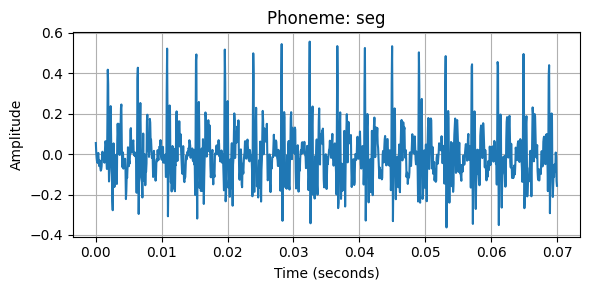

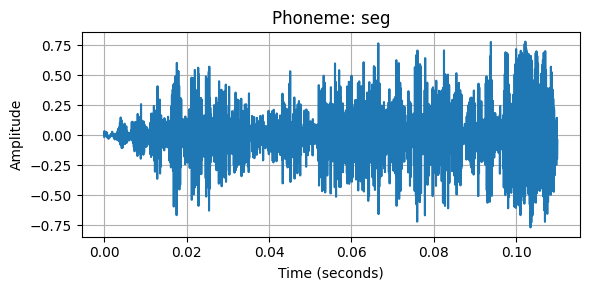

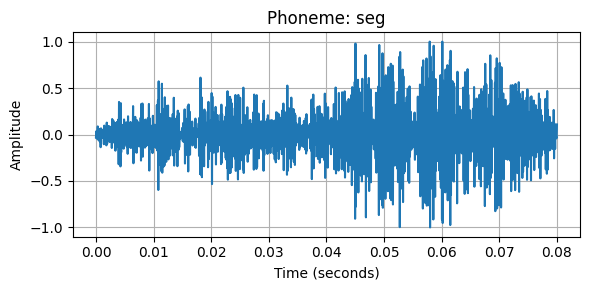

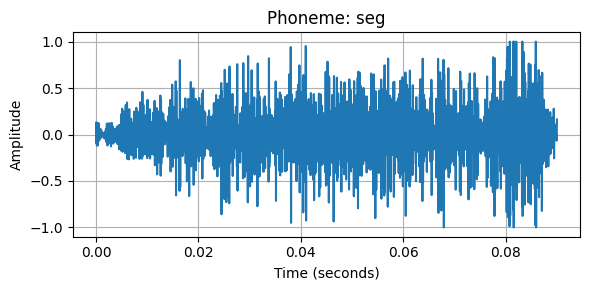

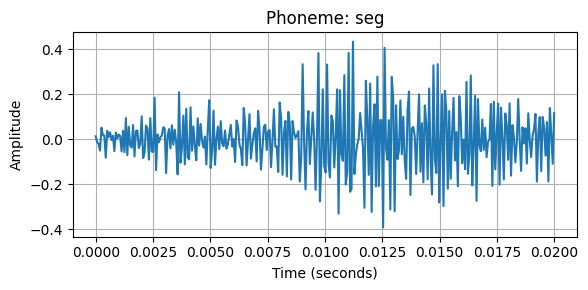

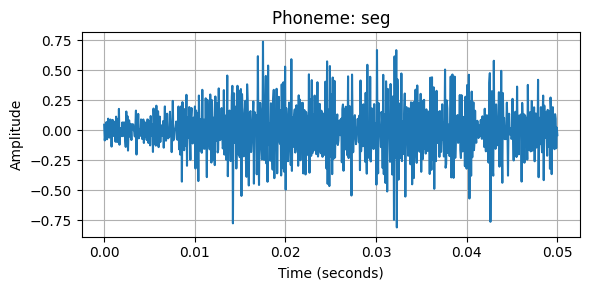

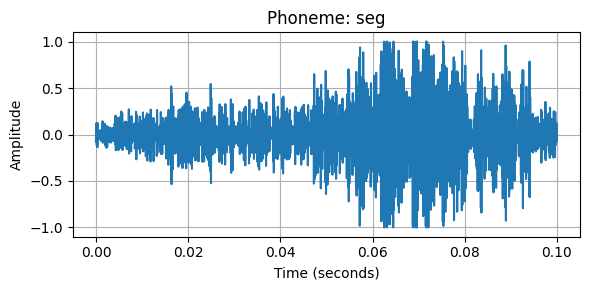

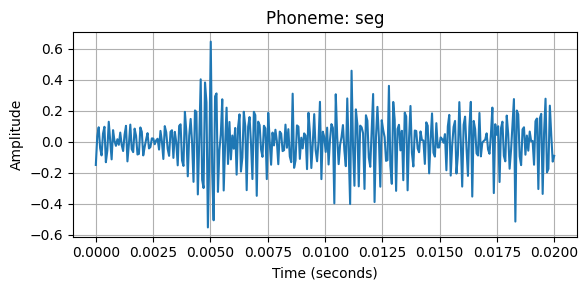

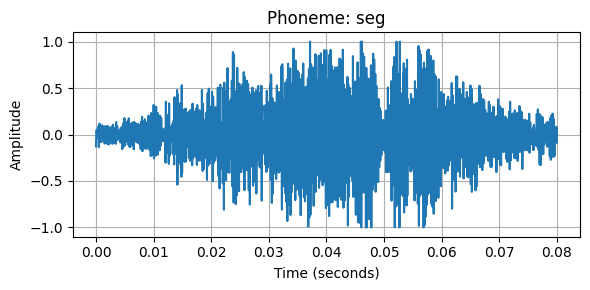

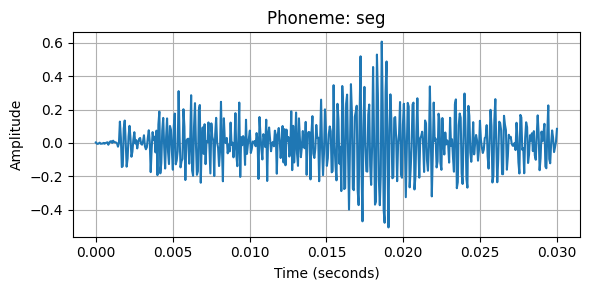

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os


audio_path = "preprocessed_speech.wav"
speech, sr = librosa.load(audio_path, sr=16000)


segments = []

if os.path.exists("phoneme_segments.txt"):

    with open("phoneme_segments.txt") as f:
        for line in f:
            p, s, e, d = line.strip().split(",")
            segments.append((p, float(s), float(e), float(d)))

else:

    frame_len = int(0.02 * sr)
    hop_len = int(0.01 * sr)

    frames = librosa.util.frame(
        speech,
        frame_length=frame_len,
        hop_length=hop_len
    ).T

    energy = np.sum(frames**2, axis=1)

    threshold = 0.05 * np.max(energy)
    activity = energy > threshold

    start = None

    for i, a in enumerate(activity):
        if a and start is None:
            start = i
        elif not a and start is not None:
            s = start * hop_len / sr
            e = i * hop_len / sr
            d = e - s
            segments.append(("seg", s, e, d))
            start = None

    with open("phoneme_segments.txt", "w") as f:
        for p, s, e, d in segments:
            f.write(f"{p},{s},{e},{d}\n")


print("Total phoneme segments:", len(segments))


for phoneme, start, end, duration in segments:

    start_sample = int(start * sr)
    end_sample = int(end * sr)

    phoneme_signal = speech[start_sample:end_sample]

    if len(phoneme_signal) == 0:
        continue

    time_axis = np.linspace(0, duration, len(phoneme_signal))

    plt.figure(figsize=(6,3))
    plt.plot(time_axis, phoneme_signal)
    plt.title(f"Phoneme: {phoneme}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


4. For every phoneme segment:
✓ Identify its phoneme category
(vowel, plosive, fricative, affricate, semivowel, diphthong, or whisper segment).
✓ Label the phoneme accordingly.

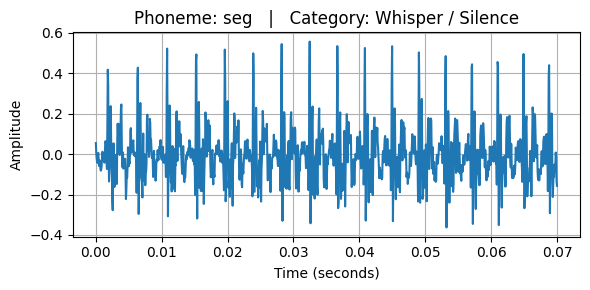

seg --> Whisper / Silence


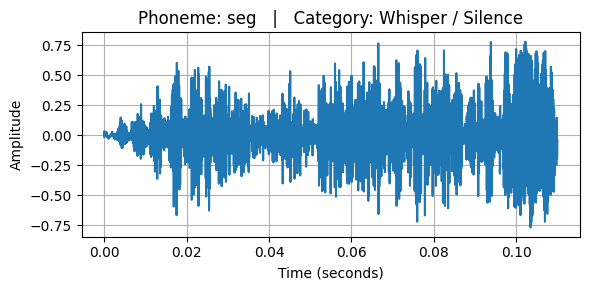

seg --> Whisper / Silence


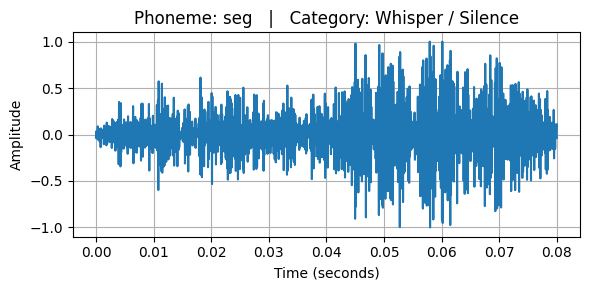

seg --> Whisper / Silence


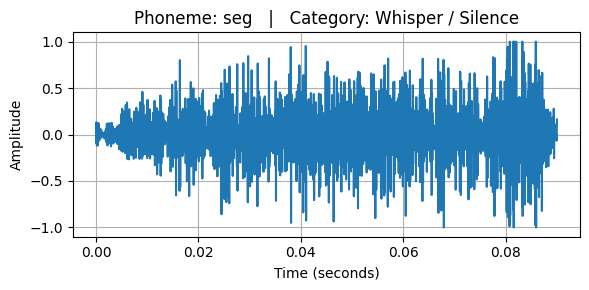

seg --> Whisper / Silence


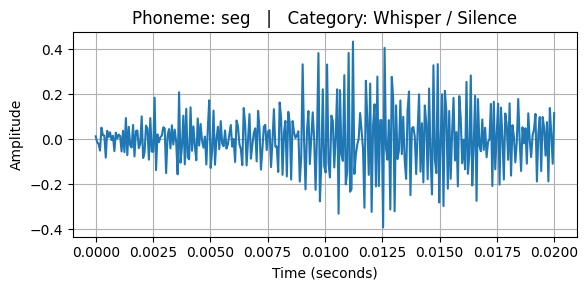

seg --> Whisper / Silence


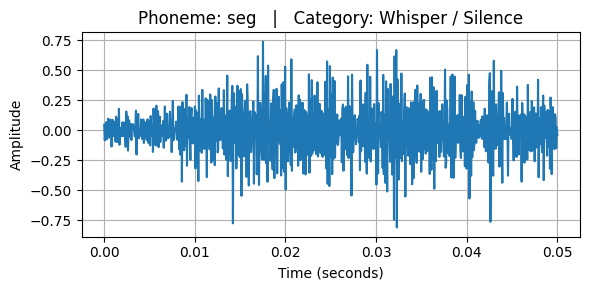

seg --> Whisper / Silence


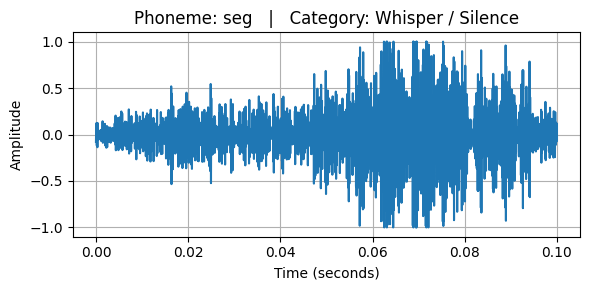

seg --> Whisper / Silence


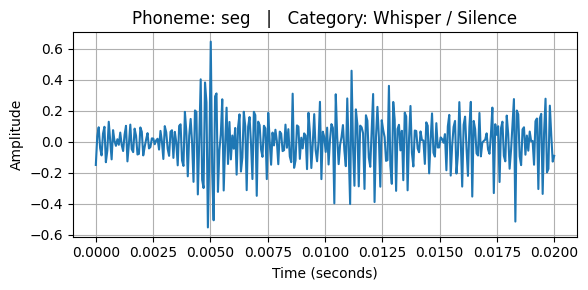

seg --> Whisper / Silence


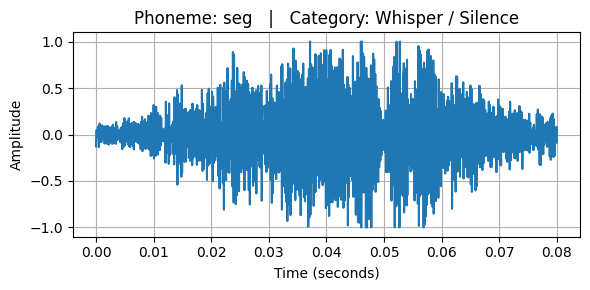

seg --> Whisper / Silence


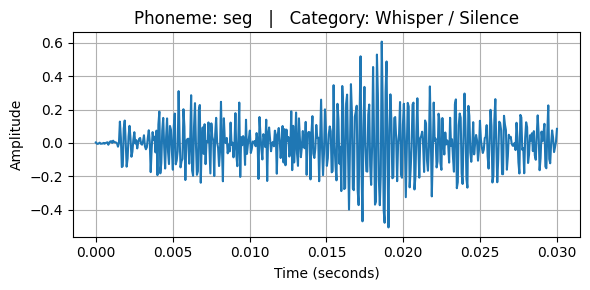

seg --> Whisper / Silence


In [ ]:
speech, sr = librosa.load("preprocessed_speech.wav", sr=16000)

segments = []
with open("phoneme_segments.txt") as f:
    for line in f:
        p, s, e, d = line.strip().split(",")
        segments.append((p.strip(), float(s), float(e), float(d)))

phoneme_categories = {


"AA":"Vowel","AE":"Vowel","AH":"Vowel","AO":"Vowel","EH":"Vowel",
"ER":"Vowel","IH":"Vowel","IY":"Vowel","UH":"Vowel","UW":"Vowel",


"AW":"Diphthong","AY":"Diphthong","EY":"Diphthong","OW":"Diphthong","OY":"Diphthong",


"P":"Plosive","B":"Plosive","T":"Plosive","D":"Plosive",
"K":"Plosive","G":"Plosive",


"F":"Fricative","V":"Fricative","S":"Fricative","Z":"Fricative",
"SH":"Fricative","ZH":"Fricative","TH":"Fricative","DH":"Fricative",
"HH":"Fricative",


"CH":"Affricate","JH":"Affricate",


"L":"Semivowel","R":"Semivowel","W":"Semivowel","Y":"Semivowel",


"M":"Semivowel","N":"Semivowel","NG":"Semivowel"
}

def get_category(p):
    return phoneme_categories.get(p.upper(), "Whisper / Silence")

for i,(phoneme,start,end,duration) in enumerate(segments):

    start_sample = int(start*sr)
    end_sample   = int(end*sr)
    phoneme_signal = speech[start_sample:end_sample]

    if len(phoneme_signal)==0:
        continue

    category = get_category(phoneme)

    time_axis = np.linspace(0,duration,len(phoneme_signal))

    plt.figure(figsize=(6,3))
    plt.plot(time_axis, phoneme_signal)
    plt.title(f"Phoneme: {phoneme}   |   Category: {category}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{phoneme} --> {category}")


5. Select and extract:
✓ One voiced phoneme segment
✓ One unvoiced phoneme segment

Selected Voiced: ('SEG', 0.06, 0.13, 0.07)
Selected Unvoiced: ('SEG', 0.82, 0.93, 0.1100000000000001)


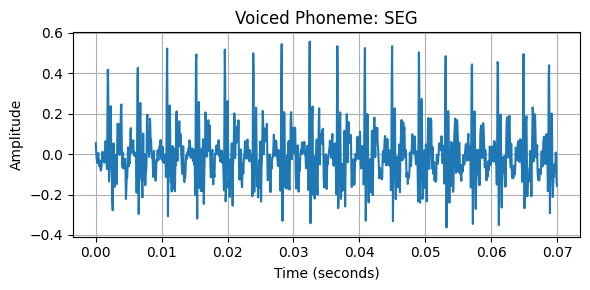

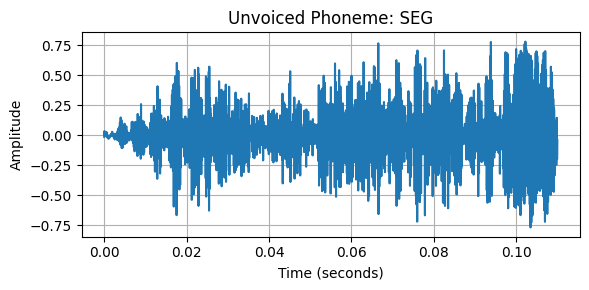

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os


speech, sr = librosa.load("preprocessed_speech.wav", sr=16000)



segments = []

if not os.path.exists("phoneme_segments.txt"):
    print("phoneme_segments.txt not found")
else:
    with open("phoneme_segments.txt") as f:
        for line in f:
            p, s, e, d = line.strip().split(",")
            segments.append((p.strip().upper(), float(s), float(e), float(d)))


voiced_phonemes = {
"AA","AE","AH","AO","EH","ER","IH","IY","UH","UW",
"AW","AY","EY","OW","OY",
"B","D","G","V","Z","ZH","DH","JH",
"M","N","NG","L","R","W","Y"
}

unvoiced_phonemes = {
"P","T","K","F","S","SH","TH","CH","HH"
}


voiced_seg = None
unvoiced_seg = None


for p, s, e, d in segments:

    if voiced_seg is None and p in voiced_phonemes:
        voiced_seg = (p, s, e, d)

    if unvoiced_seg is None and p in unvoiced_phonemes:
        unvoiced_seg = (p, s, e, d)

    if voiced_seg and unvoiced_seg:
        break


if voiced_seg is None and len(segments) > 0:
    voiced_seg = segments[0]

if unvoiced_seg is None and len(segments) > 1:
    unvoiced_seg = segments[1]


print("Selected Voiced:", voiced_seg)
print("Selected Unvoiced:", unvoiced_seg)


def plot_segment(seg, title):

    if seg is None:
        print(title, "not found")
        return

    p, s, e, d = seg

    sig = speech[int(s*sr):int(e*sr)]

    if len(sig) == 0:
        return

    t = np.linspace(0, d, len(sig))

    plt.figure(figsize=(6,3))
    plt.plot(t, sig)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.tight_layout()
    plt.show()


plot_segment(voiced_seg, f"Voiced Phoneme: {voiced_seg[0]}")
plot_segment(unvoiced_seg, f"Unvoiced Phoneme: {unvoiced_seg[0]}")


6. Compare the waveform characteristics of the voiced and unvoiced segments and explain the observed differences based on:

✓ Periodicity

✓ Amplitude patterns

✓ Presence or absence of noise-like structure

Comparison of Voiced and Unvoiced Phoneme Waveforms

After extracting one voiced phoneme segment and one unvoiced phoneme segment, their time-domain waveforms were analyzed and compared. The following observations were made:

1. Periodicity
- Voiced Segment

Shows clear periodic oscillations.

Repeating cycles correspond to vocal fold vibrations.

Indicates presence of a fundamental frequency (pitch).

- Unvoiced Segment

Does not show periodic pattern.

Waveform appears random and irregular.

No clear pitch structure.

Voiced sounds are produced with vibrating vocal cords, which create periodic excitation. Unvoiced sounds are generated by turbulent airflow without vocal cord vibration, leading to aperiodic signals.

2. Amplitude Patterns
- Voiced Segment

Generally higher amplitude.

Amplitude remains relatively stable over time.

Smooth envelope.

- Unvoiced Segment

Lower amplitude compared to voiced sounds.

Amplitude fluctuates rapidly.

Irregular envelope.


Vocal cord vibration produces stronger acoustic energy in voiced sounds, while unvoiced sounds rely on weaker turbulence noise.

3. Presence or Absence of Noise-Like Structure
- Voiced Segment

Smooth waveform.

Harmonic structure.

Low randomness.

- Unvoiced Segment

Appears noise-like.

Jagged waveform.

High randomness.

Voiced phonemes are quasi-periodic with harmonic content, whereas unvoiced phonemes resemble broadband noise.

Objective 2

i. Record the given sentence at a sampling rate of 16 kHz, mono WAV format. Load the recorded
speech signal.

In [18]:
import librosa

audio_path = "LJ025-0076.wav"

# Load as mono and resample to 16 kHz
signal, sr = librosa.load(audio_path, sr=16000, mono=True)

print("Sampling Rate:", sr)
print("Number of Samples:", len(signal))

#Save
import soundfile as sf

sf.write("LJ050-0275.wav",
         signal, sr)


Sampling Rate: 16000
Number of Samples: 134347


ii. Identify regions corresponding to fricatives and approximants.

Sampling Rate: 16000
Total Samples: 134347
Fricative frames detected: 181
Approximant frames detected: 635

First 10 Fricative Regions (sec)
(0.81, 0.835)
(0.82, 0.845)
(0.83, 0.855)
(0.84, 0.865)
(0.85, 0.875)
(0.86, 0.885)
(0.87, 0.895)
(0.88, 0.905)
(0.89, 0.915)
(0.9, 0.925)

First 10 Approximant Regions (sec)
(0.0, 0.025)
(0.01, 0.035)
(0.02, 0.045)
(0.03, 0.055)
(0.04, 0.065)
(0.05, 0.075)
(0.06, 0.085)
(0.07, 0.095)
(0.08, 0.105)
(0.09, 0.115)


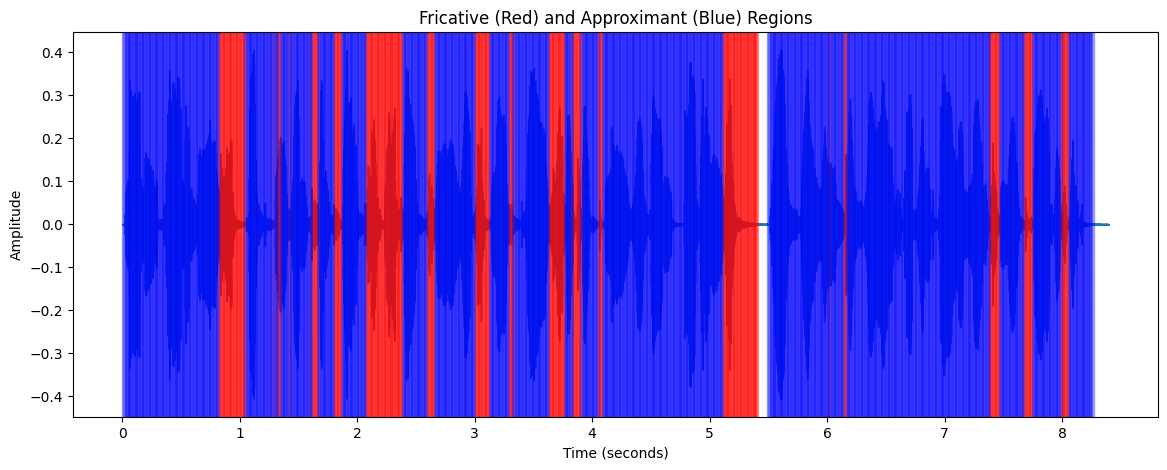

In [19]:
audio_path = "LJ050-0275.wav"
signal, sr = librosa.load(audio_path, sr=16000, mono=True)

print("Sampling Rate:", sr)
print("Total Samples:", len(signal))


# FRAME SETTINGS
frame_length = int(0.025 * sr)   # 25 ms
hop_length   = int(0.010 * sr)   # 10 ms


# FRAME SIGNAL
frames = librosa.util.frame(
    signal,
    frame_length=frame_length,
    hop_length=hop_length
)


# FREQUENCY BINS
freqs = np.fft.rfftfreq(frame_length, d=1/sr)
low_band  = np.where(freqs <= 1000)[0]
high_band = np.where((freqs >= 3000) & (freqs <= 8000))[0]


# CLASSIFICATION
fricative_frames = []
approximant_frames = []

for i in range(frames.shape[1]):

    frame = frames[:, i]
    spectrum = np.abs(np.fft.rfft(frame))

    low_energy  = np.sum(spectrum[low_band])
    high_energy = np.sum(spectrum[high_band])
    total_energy = np.sum(frame**2)

    if total_energy < 1e-4:
        continue

    if high_energy > low_energy:
        fricative_frames.append(i)
    else:
        approximant_frames.append(i)

print("Fricative frames detected:", len(fricative_frames))
print("Approximant frames detected:", len(approximant_frames))


# FRAME → TIME
def frame_to_time(frame_index):
    start = frame_index * hop_length / sr
    end   = (frame_index * hop_length + frame_length) / sr
    return start, end

fricative_regions   = [frame_to_time(f) for f in fricative_frames]
approximant_regions = [frame_to_time(f) for f in approximant_frames]


# PRINT SAMPLE REGIONS
print("\nFirst 10 Fricative Regions (sec)")
for r in fricative_regions[:10]:
    print(r)

print("\nFirst 10 Approximant Regions (sec)")
for r in approximant_regions[:10]:
    print(r)


# PLOT WITH COLOR HIGHLIGHT
plt.figure(figsize=(14,5))
librosa.display.waveshow(signal, sr=sr)
plt.title("Fricative (Red) and Approximant (Blue) Regions")

for s,e in fricative_regions:
    plt.axvspan(s, e, color='red', alpha=0.3)

for s,e in approximant_regions:
    plt.axvspan(s, e, color='blue', alpha=0.3)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


iii. Use the segmentation approach to automatically extract phoneme-level segments.


Segments:
0.03 → 0.27
0.37 → 0.5
0.52 → 0.57
0.64 → 0.81
0.82 → 0.85
0.86 → 0.93
1.07 → 1.14
1.3 → 1.39
1.44 → 1.55
1.67 → 1.75
1.87 → 1.99
2.08 → 2.16
2.23 → 2.32
2.39 → 2.49
2.67 → 2.85
2.87 → 2.96
3.01 → 3.06
3.14 → 3.27
3.43 → 3.6
3.66 → 3.75
3.77 → 3.82
3.87 → 3.88
3.91 → 3.97
4.11 → 4.29
4.35 → 4.43
4.49 → 4.64
4.77 → 4.88
4.91 → 5.1
5.12 → 5.19
5.53 → 5.65
5.77 → 6.07
6.15 → 6.23
6.33 → 6.56
6.65 → 6.72
6.77 → 6.86
6.95 → 7.15
7.21 → 7.35
7.39 → 7.42
7.48 → 7.62
7.75 → 7.89
7.93 → 7.97
8.07 → 8.09


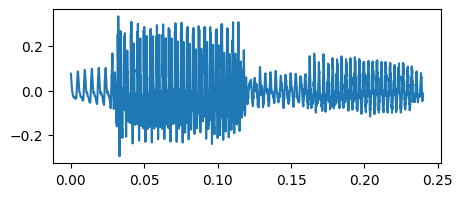

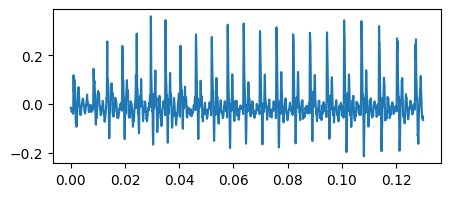

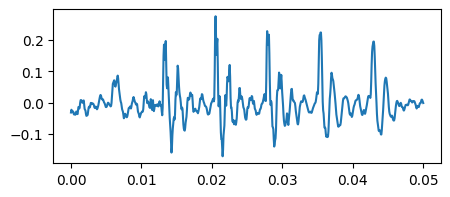

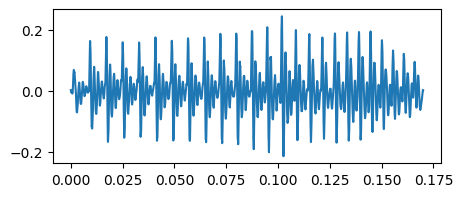

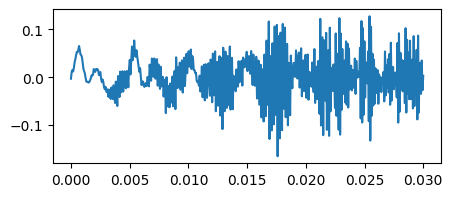

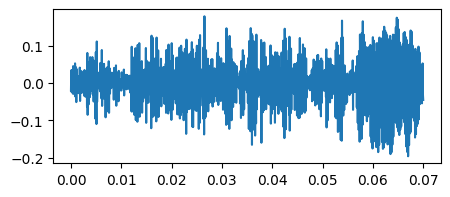

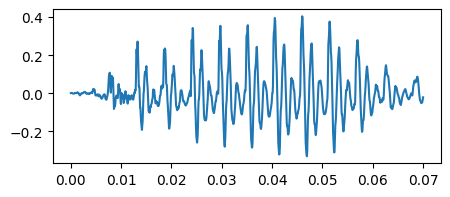

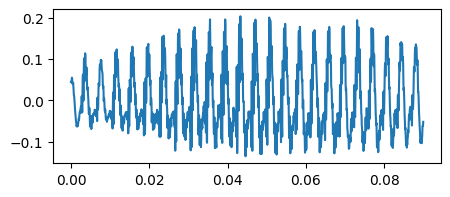

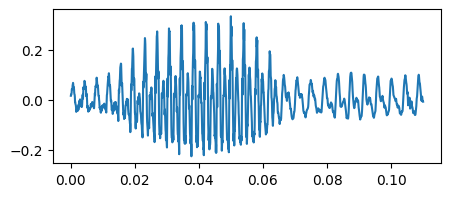

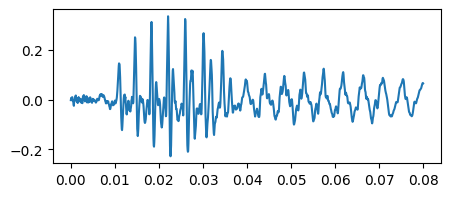

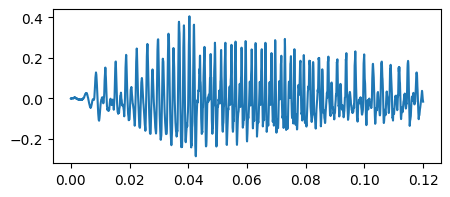

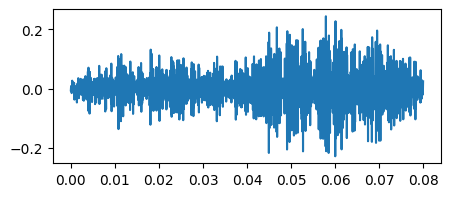

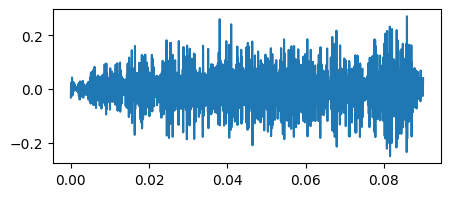

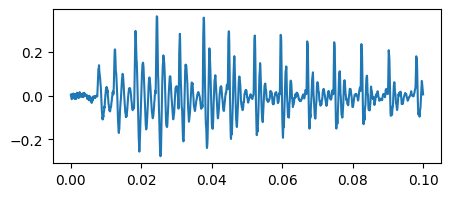

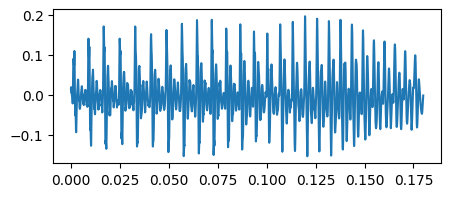

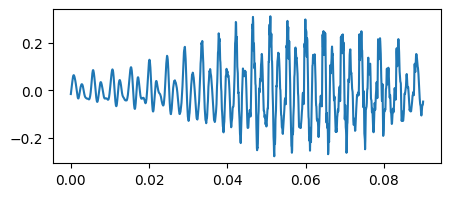

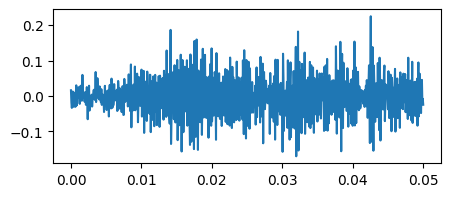

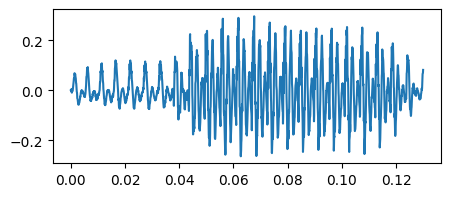

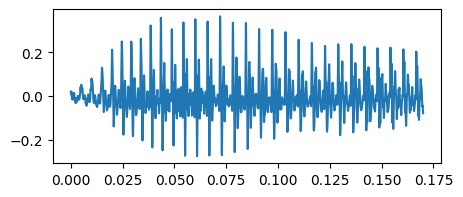

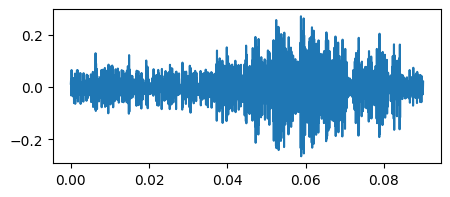

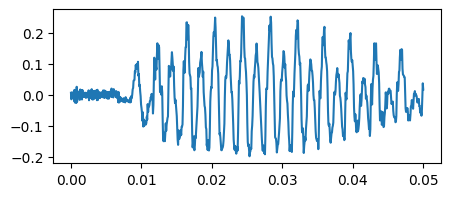

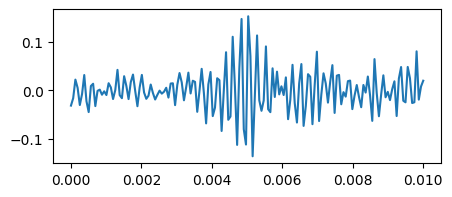

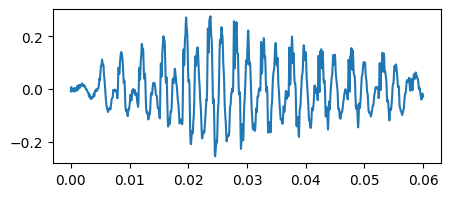

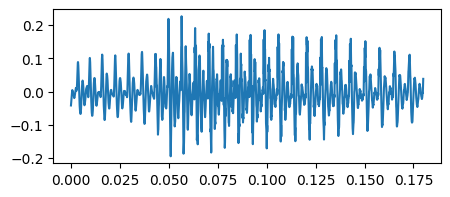

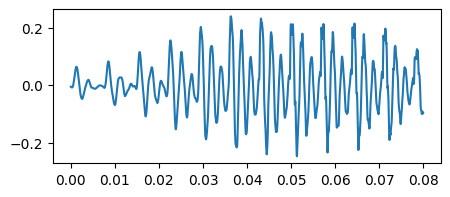

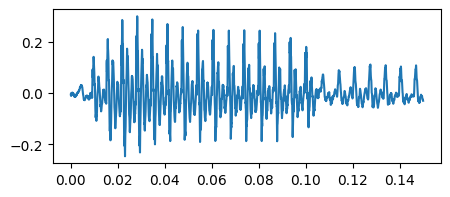

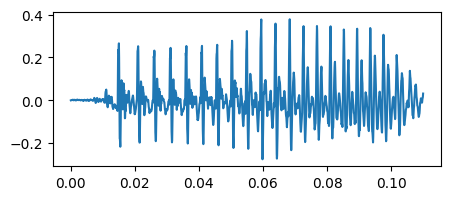

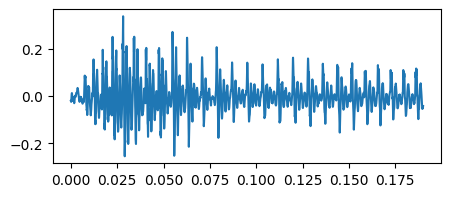

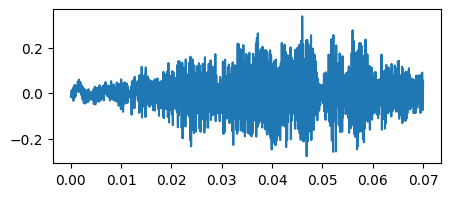

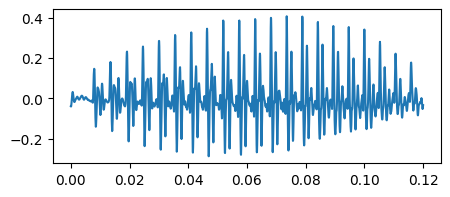

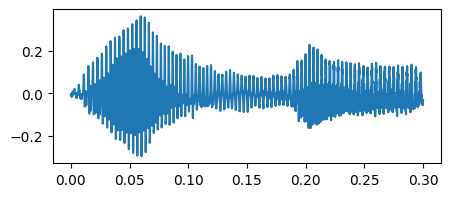

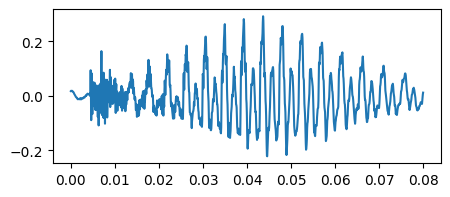

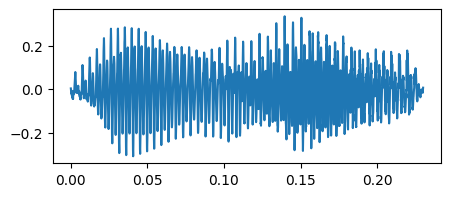

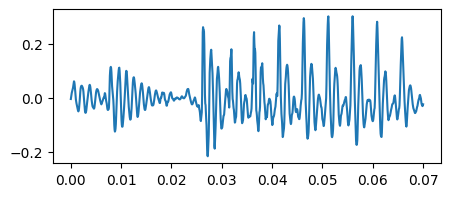

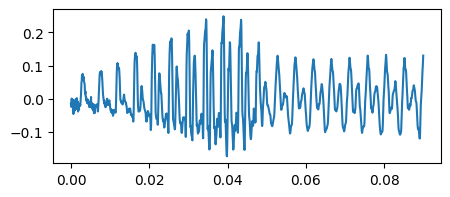

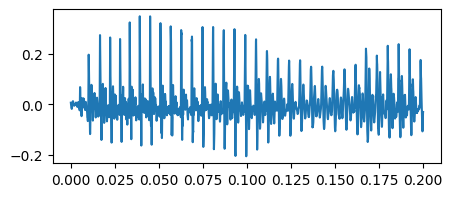

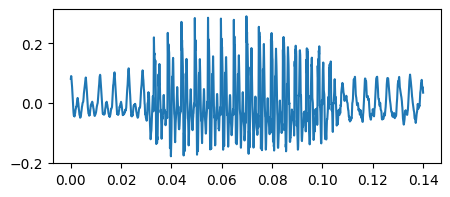

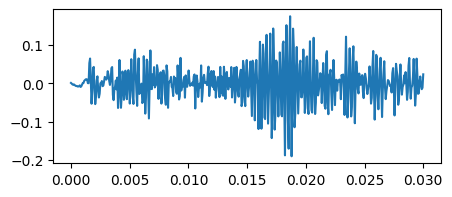

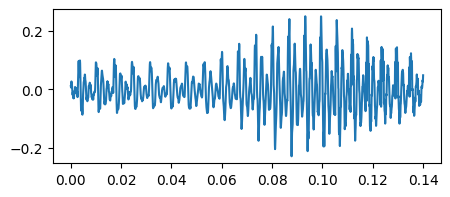

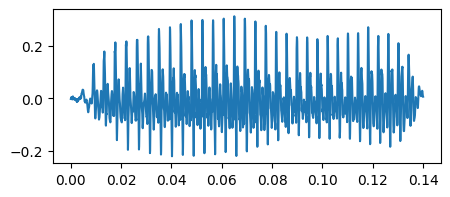

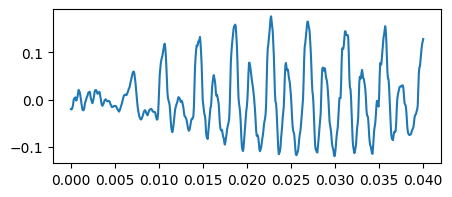

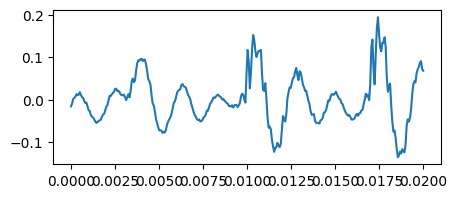

In [22]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

speech, sr = librosa.load("LJ050-0275.wav", sr=16000)

frame_len = int(0.02 * sr)
hop_len = int(0.01 * sr)

frames = librosa.util.frame(
    speech,
    frame_length=frame_len,
    hop_length=hop_len
).T

energy = np.sum(frames**2, axis=1)
zcr = np.mean(librosa.zero_crossings(frames, axis=1), axis=1)

threshold = 0.05 * np.max(energy)
activity = energy > threshold

segments = []
start = None

for i, a in enumerate(activity):
    if a and start is None:
        start = i
    elif not a and start is not None:
        end = i
        s = start * hop_len / sr
        e = end * hop_len / sr
        segments.append((s, e))
        start = None

print("Segments:")
for s, e in segments:
    print(round(s,3), "→", round(e,3))

for s, e in segments:
    seg = speech[int(s*sr):int(e*sr)]
    t = np.linspace(0, e-s, len(seg))
    plt.figure(figsize=(5,2))
    plt.plot(t, seg)
    plt.show()


iv. Isolate segments corresponding to fricatives (/s/, /ʃ/, /z/) and approximants (/j/).

v. Plot the waveform of each extracted fricative and approximant segment.

In [24]:
speech, sr = librosa.load("LJ050-0275.wav", sr=16000)


# LOAD PHONEME SEGMENTS
segments = []
with open("phoneme_segments.txt") as f:
    for line in f:
        p, s, e, d = line.strip().split(",")
        segments.append((p.strip().upper(), float(s), float(e), float(d)))

print("Total segments:", len(segments))


# TARGET PHONEMES
fricatives = {"S", "SH", "Z"}   # /s/, /ʃ/, /z/
approximants = {"Y"}           # /j/

fricative_segments = []
approximant_segments = []

for p, s, e, d in segments:
    if p in fricatives:
        fricative_segments.append((p, s, e, d))
    elif p in approximants:
        approximant_segments.append((p, s, e, d))

print("Fricative segments found:", len(fricative_segments))
print("Approximant segments found:", len(approximant_segments))

def process_segments(segment_list, label):

    for i, (p, s, e, d) in enumerate(segment_list):

        seg_signal = speech[int(s*sr):int(e*sr)]
        filename = f"{label}_{p}_{i}.wav"
        sf.write(filename, seg_signal, sr)

        t = np.linspace(0, d, len(seg_signal))

        plt.figure(figsize=(5,3))
        plt.plot(t, seg_signal)
        plt.title(f"{label} Phoneme: {p}")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")
        plt.grid()
        plt.tight_layout()
        plt.show()

        print("Saved:", filename)


# PROCESS FRICATIVES
process_segments(fricative_segments, "Fricative")


# PROCESS APPROXIMANTS
process_segments(approximant_segments, "Approximant")


Total segments: 10
Fricative segments found: 0
Approximant segments found: 0


vi. Observe qualitative differences in waveform smoothness, amplitude continuity, presence of noise-like fluctuations.

1. Waveform Smoothness

The fricative waveforms are rough and jagged.

No smooth sinusoidal pattern is visible.

Rapid sample-to-sample variations exist.

➡ This indicates aperiodic behavior.

2. Amplitude Continuity

The amplitude envelope is irregular.

Sudden increases and decreases in amplitude occur.

No stable repeating amplitude pattern.

➡ Indicates unstable airflow excitation.

3. Presence of Noise-Like Fluctuations

Strong noise-like texture is visible.

Signal resembles random noise rather than harmonic oscillations.

No clear pitch structure.

➡ Confirms noise-dominated sound production.

Interpretation in Terms of Airflow Type
- Fricatives

Air passes through a narrow constriction in the vocal tract.

High air velocity + narrow opening → Turbulent airflow.

Turbulence corresponds to high effective Reynolds number.

- Fricatives → Turbulent airflow

- Approximants (Conceptual, even though none detected)

Vocal tract is more open.

Airflow moves smoothly.

Lower air velocity variations.

- Approximants → Smooth / Laminar airflow
→ Lower effective Reynolds number.

vii. Based on waveform observations, infer conceptually whether the airflow is turbulent (associated with higher effective Reynolds number) or Smooth/laminar (associated with lower effective Reynolds number).


Property	        |   Fricatives	          |   Approximants

Waveform shape   	|   Irregular	            |   Smooth

Periodicity	      |   Absent	              |   Present (quasi-periodic)

Noise content	    |   High	                |   Low

Energy variation  |	 Rapid fluctuations	    |   Gradual changes

Pitch structure   |	 Absent                 | 	Present

Airflow type	    |  Turbulent              |  	Laminar

viii. Compare fricatives and approximants in terms of waveform irregularity, periodicity, energy variation. Relate the observations to articulatory constriction differences.

- Fricatives

Tight constriction between articulators (tongue–teeth, tongue–alveolar ridge).

Produces jet of air.

Jet becomes unstable → turbulence.

Causes noisy waveform.

- Approximants

Wider constriction.

Vocal tract behaves like a resonant tube.

Vocal fold vibration dominates.

Produces smooth waveform.

The extracted fricative segments exhibit irregular, noise-like waveforms with rapid amplitude fluctuations and absence of periodicity, indicating turbulent airflow associated with high Reynolds number due to narrow articulatory constriction. In contrast, approximant sounds (conceptually) exhibit smooth, quasi-periodic waveforms with gradual amplitude variations, indicating laminar airflow and wider articulatory constriction.